# ¿El SD sin el requisito de reconstrucción coincide con el UMD?

Ésta es la comparación que faltaba: **poner el SD antes del corte y el UMD
en el mismo gráfico, y calcular su diferencia**, no solamente demostrar que
desaparece el signo negativo del SD.

No ajustamos una corrección al UMD ni sumamos un desplazamiento elegido a mano.
Volvemos a calcular A1 con los conteos SD que ya estaban guardados en ADST,
incluyendo estaciones sin contraparte reconstruida. La curva UMD sigue siendo
la de tu parquet original. Por tanto ésta es una comparación **SD antes del
requisito HasStation vs UMD con la selección original**, no dos poblaciones
completamente libres de selección.

Convención en todo el cuaderno: A1 > 0 = exceso temprano; A1 < 0 = exceso tardío.
Delta = A1(SD) - A1(UMD): Delta negativo significa que SD es menos temprano
que UMD; NO significa necesariamente que el propio SD tenga A1 negativo.

Sólo lectura de insumos. Sin ROOT, Offline, simulaciones nuevas ni modificaciones
a la tesis. Todas las salidas quedan en esta carpeta; reejecutar reemplaza sólo
las salidas generadas por este cuaderno. Cálculo monoproceso de tablas pequeñas.

In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown

thread_limit = threadpool_limits(limits=1)
started = time.monotonic()
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'CLAUDE.md').is_file())
HERE = REPO / 'claude_work/revision_asimetrias_sd_umd/02_notebooks/03_sd_vs_umd'
RESULTS = HERE / 'resultados'
RESULTS.mkdir(exist_ok=True)
AUDIT = REPO / 'claude_work/revision_asimetrias_sd_umd/04_soporte/tablas'
PREVIOUS = REPO / 'claude_work/revision_asimetrias_sd_umd/02_notebooks/02_reproduccion'
PARQUET = Path('/home/lsilva/Github/ADST_Alexey_module_v11/parquet_sib_proton_17')
R_EDGES = np.array([150, 300, 450, 600, 750, 900, 1050, 1200, 1350])
R_CENTERS = (R_EDGES[:-1] + R_EDGES[1:]) / 2
PHI_EDGES = np.linspace(-180, 180, 13)
PHI_CENTERS = (PHI_EDGES[:-1] + PHI_EDGES[1:]) / 2
COS = np.cos(np.deg2rad(PHI_CENTERS))
N_BOOTSTRAP = 1200
SEED = 20260911
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': .25})
pd.set_option('display.max_columns', 20)

## 1. De dónde sale cada curva

| Curva | Insumo | Unidad del promedio | Selección |
|---|---|---|---|
| UMD original | Parquet, nMuones_MC | Módulo UMD | La del lector original, incluido HasStation |
| SD después | ADST extraído, mu | Una estación SD por evento guardado | HasStation=True |
| SD antes | La misma extracción ADST, mu | Una estación SD por evento guardado | No exigir HasStation |

La extracción `adst_counts_fast.csv` contiene **filas de estaciones y sus
conteos**, no coeficientes preajustados. Su procedencia y cómo regenerarla se
explican en `../01_seleccion/seleccion_sd_paso_a_paso.ipynb`;
el lector legible es `../01_seleccion/read_original_adst.py`.
Lee GetSimStationVector y GetNumberOfMuons sin descartar HasStation=False.

“Antes” NO significa todas las lluvias CORSIKA ni todo el flujo en el suelo:
siguen presentes la selección de eventos guardados en ADST, la disponibilidad
de estaciones simuladas y los límites de la extracción. No se reconstruyen
estaciones ausentes; se leen sus conteos de simulación ya existentes.

Elegimos exactamente 30 <= theta_MC < 40 grados, las ocho bandas de tu figura,
doce bins phi, y tu ajuste ponderado por SEM. Para SD no repetimos la misma
estación por cada módulo UMD. El UMD conserva sus filas originales por módulo.

In [2]:
raw = pd.read_csv(AUDIT / 'adst_counts_fast.csv', dtype={'event_id': str, 'source': str})
assert raw.theta.between(30, 40, inclusive='left').all()
raw['radius'] = raw.r
raw['phi_deg'] = np.rad2deg(raw.phi)
columns = ['event_id', 'counterId', 'sdId', 'moduleId', 'theta_MC', 'r_core_MC',
           'phi_plane_euler_MC_true_core', 'nMuones_MC', 'sd_nMuons_MC']
parts = []
for filename in sorted(PARQUET.glob('*.parquet')):
    part = pd.read_parquet(filename, columns=columns)
    part['source'] = filename.with_suffix('.root').name
    parts.append(part)
assert parts
modules = pd.concat(parts, ignore_index=True)
modules = modules.loc[(modules.counterId >= 100000)
                      & modules.theta_MC.between(30, 40, inclusive='left')].copy()
modules['event_id'] = modules.event_id.astype(str)
modules['radius'] = modules.r_core_MC
# La columna está guardada en radianes. Misma transformación que tu figura.
assert modules.phi_plane_euler_MC_true_core.between(0, 2*np.pi).all()
euler_abs = (np.rad2deg(modules.phi_plane_euler_MC_true_core) - 180) % 360
modules['phi_deg'] = (euler_abs + 180) % 360 - 180
KEY = ['source', 'event_id', 'sdId']
assert not raw.duplicated(KEY).any()
assert modules.groupby(KEY).sd_nMuons_MC.nunique().eq(1).all()
unique_sd = modules.drop_duplicates(KEY)
unique_sd = unique_sd.loc[unique_sd.radius.between(150, 1800, inclusive='left')]
matched = raw.merge(unique_sd[KEY + ['sd_nMuons_MC', 'phi_deg', 'radius']],
                    on=KEY, how='outer', indicator=True, validate='one_to_one',
                    suffixes=('_adst', '_parquet'))
assert not matched._merge.eq('right_only').any()
assert np.array_equal(matched.has_rec.eq(1), matched._merge.eq('both'))
both = matched.loc[matched._merge.eq('both')]
assert np.array_equal(both.mu, both.sd_nMuons_MC)
assert np.allclose(both.radius_adst, both.radius_parquet, atol=1e-6, rtol=0)
assert np.max(abs((both.phi_deg_adst - both.phi_deg_parquet + 180) % 360 - 180)) < 1e-6

samples = {
    'UMD_original': (modules, 'nMuones_MC'),
    'SD_antes': (raw, 'mu'),
    'SD_despues': (raw.loc[raw.has_rec.eq(1)].copy(), 'mu'),
}
display(pd.DataFrame([
    {'muestra': name, 'filas_150_1350m': int(table.radius.between(150, 1350, inclusive='left').sum()),
     'archivos': table.source.nunique()}
    for name, (table, _) in samples.items()
]))
print('Control: SD seleccionado y parquet coinciden estación por estación.')

,muestra,filas_150_1350m,archivos
0,UMD_original,145281,20
1,SD_antes,63398,20
2,SD_despues,48427,20


Control: SD seleccionado y parquet coinciden estación por estación.


## 2. Misma definición del ajuste y un atajo algebraico verificable

Por bin phi obtenemos media m y SEM s. Definimos M = promedio de las doce
medias, y=m/M, e=s/M. El modelo es 1+A cos(phi); no tiene intercepto libre.
Su mínimo de chi cuadrado tiene solución exacta:

A = sum[cos(phi)*(y-1)/e²] / sum[cos²(phi)/e²].

Es el mismo problema de curve_fit, limitado al intervalo [-2,2]. Verificamos
ambos resultados abajo. Esta forma evita miles de optimizaciones durante el
bootstrap. **No es un nuevo modelo físico ni un cambio de estimador.**

Guardamos suma, suma de cuadrados y número de filas por bin. Eso basta para
recalcular medias, SEM y A en cada remuestreo. La SEM interna mantiene tu
definición; la incertidumbre final se obtiene remuestreando lluvias completas.

In [3]:
def fit_moments(moments):
    """Últimos ejes: (n, suma, suma_cuadrados), phi. Admite lotes de réplicas."""
    n, total, squares = np.moveaxis(moments, -2, 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        means = total / n
        sem2 = np.maximum(squares - total**2 / n, 0) / (n * (n - 1))
        norm = np.nanmean(means, axis=-1, keepdims=True)
        y = means / norm
        err2 = sem2 / norm**2
        valid = (n > 1) & np.isfinite(y) & np.isfinite(err2) & (err2 > 0)
        w = np.where(valid, 1 / err2, 0)
        denominator = np.sum(w * COS**2, axis=-1)
        numerator = np.sum(np.where(valid, w * COS * (y - 1), 0), axis=-1)
        a = np.clip(numerator / denominator, -2, 2)
        error = np.sqrt(1 / denominator)
        good = (valid.sum(axis=-1) >= 5) & (n.sum(axis=-1) >= 15) & (norm[..., 0] > 0) & (error <= .5)
    return np.where(good, a, np.nan), np.where(good, error, np.nan)

# El identificador completo contiene biblioteca, Run y Shower.
# Quitamos SOLO Use_N: distintas reutilizaciones de una lluvia siguen juntas.
# No añadimos source a este grupo: una misma lluvia reutilizada en dos archivos
# debe recibir el mismo peso. source sí forma parte de la clave de fila anterior.
parent_ids = raw.event_id.str.replace(r':Use_\d+$', '', regex=True)
parents = pd.Index(sorted(parent_ids.unique()))
P = len(parents)
moment_tables = []
for name, (table, column) in samples.items():
    t = table.loc[table.radius.between(150, 1350, inclusive='left')].copy()
    t['radial_bin'] = pd.cut(t.radius, R_EDGES, right=False, labels=False)
    # Defaults originales: -180 exacto queda fuera; +180 queda dentro.
    t['phi_bin'] = pd.cut(t.phi_deg, PHI_EDGES, labels=False)
    t = t.dropna(subset=[column, 'phi_bin', 'radial_bin'])
    parent = t.event_id.str.replace(r':Use_\d+$', '', regex=True)
    index = parents.get_indexer(parent)
    assert (index >= 0).all(), 'Hay una lluvia UMD sin grupo SD correspondiente.'
    array = np.zeros((P, 8, 3, 12))
    r, phi, values = t.radial_bin.to_numpy(int), t.phi_bin.to_numpy(int), t[column].to_numpy(float)
    for k, value in enumerate([np.ones(len(t)), values, values**2]):
        np.add.at(array, (index, r, k, phi), value)
    moment_tables.append(array)

# Ejes: lluvia, observable, banda radial, momento, phi.
moments = np.stack(moment_tables, axis=1)
point, formal_error = fit_moments(moments.sum(axis=0))
names = list(samples)
for j, (name, (table, column)) in enumerate(samples.items()):
    for k, (lo, hi) in enumerate(zip(R_EDGES[:-1], R_EDGES[1:])):
        t = table.loc[table.radius.between(lo, hi, inclusive='left')].copy()
        stats = t.groupby(pd.cut(t.phi_deg, PHI_EDGES), observed=False)[column].agg(['mean', 'sem'])
        norm = stats['mean'].mean()
        popt, _ = curve_fit(lambda phi, a: 1 + a*np.cos(np.deg2rad(phi)),
                            PHI_CENTERS, stats['mean']/norm, sigma=stats['sem']/norm,
                            absolute_sigma=True, bounds=(-2., 2.))
        assert abs(popt[0] - point[j, k]) < 1e-7

# Chequeo adicional contra las cifras ya verificadas con tu PDF, sin usarlas
# para obtener los nuevos coeficientes.
old = pd.read_csv(PREVIOUS / 'resultados' / 'ajustes_reproducidos.csv')
assert np.allclose(point[0], old.loc[old.column.eq('nMuones_MC'), 'A1'], atol=1e-7, rtol=0)
old_sd = pd.read_csv(PREVIOUS / 'resultados' / 'seleccion_mismos_bins_ajuste_ponderado.csv')
for j, label in [(1, 'Antes de HasStation'), (2, 'HasStation=True')]:
    expected = old_sd.loc[old_sd.column.eq('sd_nMuons_MC') & old_sd['sample'].eq(label), 'A1']
    assert np.allclose(point[j], expected, atol=1e-7, rtol=0)
print('Ajuste algebraico = curve_fit; curvas originales reproducidas. Grupos de lluvia:', P)

Ajuste algebraico = curve_fit; curvas originales reproducidas. Grupos de lluvia: 960


## 3. ¿Qué significa que coincidan? Comparar la diferencia pareada

No basta con mirar si las barras de SD y UMD se superponen. Comparten lluvias,
por lo que sus errores están correlacionados. Para cada réplica sorteamos
**las mismas lluvias** para UMD, SD antes y SD después, manteniendo juntos
sus módulos, estaciones y reutilizaciones. Recalculamos también los pesos SEM.

Esto conserva la definición de A de tu figura, pero cambia sus barras formales
por una estimación de incertidumbre que contempla esas dependencias.
El modelo estadístico supone independencia entre identificadores de lluvia
progenitora; no estima sistemáticas de detector ni errores de modelo hadrónico.

Damos intervalos percentiles puntuales del 95% para Delta y una banda simultánea
aproximada, mediante el máximo de las desviaciones bootstrap estandarizadas
entre las ocho bandas. La banda simultánea protege contra elegir a posteriori
el radio más discrepante. **Que cero quede dentro no prueba igualdad física**:
significa que no se resuelve una diferencia con esta precisión y procedimiento.

In [4]:
rng = np.random.default_rng(SEED)
draws = []
flat = moments.reshape(P, -1)
for first in range(0, N_BOOTSTRAP, 40):
    size = min(40, N_BOOTSTRAP - first)
    weights = rng.multinomial(P, np.full(P, 1/P), size=size)
    summed = (weights @ flat).reshape(size, 3, 8, 3, 12)
    values, _ = fit_moments(summed)
    draws.append(values)
draws = np.concatenate(draws)
assert np.isfinite(draws).all(), 'Revisar réplicas inválidas; no descartarlas silenciosamente.'
boot_sd = draws.std(axis=0, ddof=1)
differences = np.stack([draws[:, 1] - draws[:, 0], draws[:, 2] - draws[:, 0]], axis=1)
delta = np.stack([point[1] - point[0], point[2] - point[0]])
ci = np.quantile(differences, [.025, .975], axis=0)
delta_sd = differences.std(axis=0, ddof=1)
# Banda simultánea sólo para la pregunta principal: SD antes vs UMD original.
max_deviation = np.max(abs((differences[:, 0] - differences[:, 0].mean(axis=0)) / delta_sd[0]), axis=1)
critical = np.quantile(max_deviation, .95)
sim_low, sim_high = delta[0] - critical*delta_sd[0], delta[0] + critical*delta_sd[0]

result = pd.DataFrame({
    'r_min': R_EDGES[:-1], 'r_max': R_EDGES[1:], 'r_center': R_CENTERS,
    'A_UMD_original': point[0], 'A_SD_antes': point[1], 'A_SD_despues': point[2],
    'sigma_boot_UMD': boot_sd[0], 'sigma_boot_SD_antes': boot_sd[1],
    'sigma_boot_SD_despues': boot_sd[2],
    'delta_antes_menos_UMD': delta[0], 'delta_antes_low95': ci[0, 0], 'delta_antes_high95': ci[1, 0],
    'delta_antes_sim_low95': sim_low, 'delta_antes_sim_high95': sim_high,
    'delta_despues_menos_UMD': delta[1],
    'delta_despues_low95': ci[0, 1], 'delta_despues_high95': ci[1, 1],
})
result.to_csv(RESULTS / 'comparacion_directa.csv', index=False)
replicate_table = pd.DataFrame(draws.reshape(N_BOOTSTRAP, -1), columns=[
    f'{name}_r{int(r)}' for name in names for r in R_CENTERS])
replicate_table.to_csv(RESULTS / 'replicas_pareadas.csv', index=False)
display(result.round(5))
print('Réplicas válidas:', len(draws), '| semilla:', SEED, '| factor simultáneo:', critical)

,r_min,r_max,r_center,A_UMD_original,A_SD_antes,A_SD_despues,sigma_boot_UMD,sigma_boot_SD_antes,sigma_boot_SD_despues,delta_antes_menos_UMD,delta_antes_low95,delta_antes_high95,delta_antes_sim_low95,delta_antes_sim_high95,delta_despues_menos_UMD,delta_despues_low95,delta_despues_high95
0,150,300,225.0,0.06196,0.03314,0.03314,0.01650,0.01682,0.01682,-0.02882,-0.04103,-0.01637,-0.04545,-0.01218,-0.02882,-0.04103,-0.01637
1,300,450,375.0,0.09326,0.06017,0.06017,0.00894,0.00918,0.00918,-0.03309,-0.04736,-0.01965,-0.05223,-0.01395,-0.03309,-0.04736,-0.01965
2,450,600,525.0,0.08530,0.05883,0.05883,0.00940,0.00980,0.00980,-0.02647,-0.04270,-0.00914,-0.04919,-0.00375,-0.02647,-0.04270,-0.00914
3,600,750,675.0,0.11472,0.06045,0.05933,0.00876,0.00900,0.00903,-0.05427,-0.07417,-0.03473,-0.08114,-0.02739,-0.05539,-0.07527,-0.03550
4,750,900,825.0,0.11478,0.05756,0.04021,0.01101,0.01069,0.01082,-0.05722,-0.08422,-0.03019,-0.09271,-0.02173,-0.07457,-0.10096,-0.04806
5,900,1050,975.0,0.09410,0.06602,-0.01580,0.01385,0.01202,0.01189,-0.02808,-0.06066,0.00626,-0.07287,0.01671,-0.10990,-0.14211,-0.07919
6,1050,1200,1125.0,0.10567,0.06826,-0.06412,0.01898,0.01327,0.01393,-0.03741,-0.08036,0.00504,-0.09711,0.02229,-0.16979,-0.21134,-0.12574
7,1200,1350,1275.0,0.08160,0.06887,-0.12399,0.03437,0.01568,0.01857,-0.01273,-0.08967,0.05549,-0.11098,0.08552,-0.20559,-0.28502,-0.13075


Réplicas válidas: 1200 | semilla: 20260911 | factor simultáneo: 2.669599090306987


## 4. El gráfico que responde tu pregunta

Arriba: UMD original, SD antes y SD después en **el mismo eje**. Las barras son
una desviación estándar bootstrap, no las SEM formales de la figura original.
Abajo: SD menos UMD, con intervalos puntuales del 95%. La banda tenue es el
intervalo simultáneo para la comparación principal (SD antes menos UMD).

Si la curva SD antes se acerca a UMD pero permanece separada de él, la conclusión
correcta es que el corte explica la inversión, **no** que transforma SD en UMD.

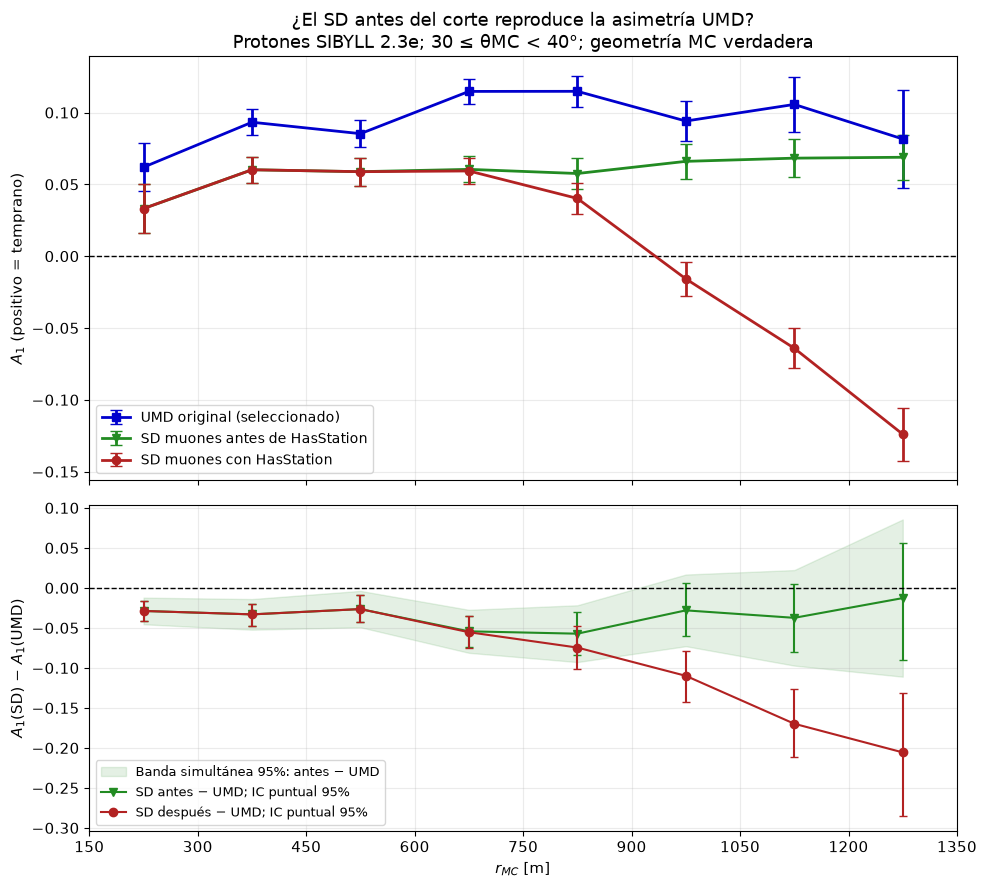

In [5]:
fig, (ax, dx) = plt.subplots(2, 1, figsize=(10, 9), sharex=True,
                             gridspec_kw={'height_ratios': [1.3, 1]})
styles = [('UMD original (seleccionado)', 'mediumblue', 's'),
          ('SD muones antes de HasStation', 'forestgreen', 'v'),
          ('SD muones con HasStation', 'firebrick', 'o')]
for j, (label, color, marker) in enumerate(styles):
    ax.errorbar(R_CENTERS, point[j], yerr=boot_sd[j], label=label,
                color=color, marker=marker, capsize=4, lw=2)
ax.axhline(0, color='black', ls='--', lw=1)
ax.set_ylabel('$A_1$ (positivo = temprano)')
ax.legend(loc='lower left', fontsize=10)
ax.set_title('¿El SD antes del corte reproduce la asimetría UMD?\n'
             'Protones SIBYLL 2.3e; 30 ≤ θMC < 40°; geometría MC verdadera')
dx.fill_between(R_CENTERS, sim_low, sim_high, color='forestgreen', alpha=.12,
                label='Banda simultánea 95%: antes − UMD')
for j, (label, color, marker) in enumerate([
    ('SD antes − UMD; IC puntual 95%', 'forestgreen', 'v'),
    ('SD después − UMD; IC puntual 95%', 'firebrick', 'o')]):
    # Dibujar límites directamente evita presuponer que todo IC contiene el estimador.
    dx.plot(R_CENTERS, delta[j], color=color, marker=marker, label=label)
    dx.vlines(R_CENTERS, ci[0, j], ci[1, j], color=color)
    dx.plot(R_CENTERS, ci[0, j], '_', color=color)
    dx.plot(R_CENTERS, ci[1, j], '_', color=color)
dx.axhline(0, color='black', ls='--', lw=1)
dx.set_ylabel('$A_1$(SD) − $A_1$(UMD)')
dx.set_xlabel('$r_{MC}$ [m]')
dx.set_xticks(R_EDGES)
dx.legend(loc='lower left', fontsize=9)
fig.tight_layout()
fig.savefig(RESULTS / 'SD_sin_corte_vs_UMD.pdf')
fig.savefig(RESULTS / 'SD_sin_corte_vs_UMD.png', dpi=170)
plt.show()

## 5. Interpretación física: lo demostrado y lo que no

**Establecido para esta muestra:** retirar únicamente el requisito de presencia
reconstruida SD cambia el promedio azimutal de sus conteos MC. Usar coordenadas
MC no deshace la selección de filas. No cambiamos las trayectorias, el suelo,
la atenuación ni la respuesta de los detectores: cambia qué estaciones entran
en el promedio. El contraste antes/después es sobre la misma extracción SD.

**No establecido:** que SD y UMD deban tener A1 idéntico. Son observables
diferentes: conteo de inyección en SD y conteo MC por módulo UMD bajo tierra.
Tu trabajo previo distingue su aceptación geométrica y selección en energía.
La igualdad de signos no implica igualdad de amplitudes; quitar HasStation
del SD no lo convierte en un detector enterrado.

**Limitación importante:** aquí UMD continúa seleccionado. El piloto previo
encontró resúmenes MC UMD ausentes, no recuperables como conteos físicos nulos,
en estaciones que la selección SD descarta. Por eso no dibujamos una supuesta
curva UMD sin selección rellenando ceros. La diferencia residual no puede
atribuirse exclusivamente a física del transporte o del detector.

Para una comparación sin selección en ambos detectores se necesitan resúmenes
UMD válidos también cuando no hay estación SD reconstruida. Para probar sólo
si la curva SD ampliada se aproxima a **tu curva UMD actual**, estos datos sí
bastan: ésa es exactamente la pregunta cuantificada aquí.

Tampoco se valida por este acuerdo parcial la predicción analítica SD anterior:
estamos comparando dos estimadores del MC, no ajustando ni comprobando de nuevo
un modelo de atenuación + geometría + divergencia cinemática.

In [6]:
lines = ['# ¿Coincide el SD antes del requisito de reconstrucción con el UMD?', '',
         'Comparación directa con la curva UMD original, no con un UMD libre de selección.', '',
         'A1 positivo = exceso temprano. Delta = SD antes − UMD.', '',
         '| r [m] | UMD original | SD antes | SD después | Delta | IC puntual 95% de Delta |',
         '|---|---:|---:|---:|---:|---:|']
for row in result.itertuples():
    lines.append(f'| {row.r_min}–{row.r_max} | {row.A_UMD_original:+.4f} | '
                 f'{row.A_SD_antes:+.4f} | {row.A_SD_despues:+.4f} | '
                 f'{row.delta_antes_menos_UMD:+.4f} | '
                 f'[{row.delta_antes_low95:+.4f}, {row.delta_antes_high95:+.4f}] |')
excluded = result.loc[(sim_low > 0) | (sim_high < 0)]
bands = ', '.join(f'{int(row.r_min)}–{int(row.r_max)} m' for row in excluded.itertuples()) or 'ninguna'
lines += ['', f'Bootstrap pareado: {P} grupos de lluvia progenitora, {N_BOOTSTRAP} réplicas, '
          f'semilla {SEED}. Se mantienen juntos módulos, estaciones y reutilizaciones.', '',
          f'Bandas cuyo intervalo simultáneo aproximado del 95% excluye Delta=0: {bands}.', '',
          'La compatibilidad local no prueba igualdad. La comparación global no debe decidirse '
          'sólo por el último punto. Las bandas simultáneas están en comparacion_directa.csv.', '',
          'Retirar HasStation elimina la inversión SD en esta muestra; no hace idénticas las '
          'dos curvas. UMD conserva la selección original. Esto no prueba un fallo de Offline '
          'ni identifica el origen físico de toda diferencia residual.', '',
          '## Reproducción y procedencia', '',
          '- Abrir comparar_sd_umd.ipynb y ejecutar todas las celdas con el venv del repo.',
          '- Código fuente legible: comparar_sd_umd.py (jupytext). HTML: comparar_sd_umd.html.',
          '- SD: ../../04_soporte/tablas/adst_counts_fast.csv, extracción de conteos '
          'por estación de los ADST originales; no contiene ajustes prefijados.',
          '- UMD: parquet original de ADST_Alexey_module_v11/parquet_sib_proton_17/.',
          '- Lector ADST documentado: ../01_seleccion/read_original_adst.py.',
          '- Verificado: SD retenido coincide fila a fila con parquet; UMD reproduce la figura '
          'original; solución algebraica coincide con curve_fit en las 24 combinaciones.',
          '- Ocho bandas radiales originales, 12 bins phi, ajuste ponderado; SD sin duplicados '
          'por módulo. Barras de la nueva figura: bootstrap, no errores formales independientes.',
          '- No se ejecutó ROOT ni se modificó software, configuración o datos externos.', '',
          '## Límite físico', '',
          'Antes del requisito HasStation no equivale a ausencia de todo corte: se conservan '
          'los eventos guardados y estaciones simuladas disponibles. Falta UMD no seleccionado '
          'válido para separar de forma concluyente física del detector y selección residual.']
report = '\n'.join(lines) + '\n'
(HERE / 'RESULTADO.md').write_text(report, encoding='utf-8')
display(Markdown(report))
print(f'Tiempo total del cálculo: {time.monotonic() - started:.1f} s')

# ¿Coincide el SD antes del requisito de reconstrucción con el UMD?

Comparación directa con la curva UMD original, no con un UMD libre de selección.

A1 positivo = exceso temprano. Delta = SD antes − UMD.

| r [m] | UMD original | SD antes | SD después | Delta | IC puntual 95% de Delta |
|---|---:|---:|---:|---:|---:|
| 150–300 | +0.0620 | +0.0331 | +0.0331 | -0.0288 | [-0.0410, -0.0164] |
| 300–450 | +0.0933 | +0.0602 | +0.0602 | -0.0331 | [-0.0474, -0.0196] |
| 450–600 | +0.0853 | +0.0588 | +0.0588 | -0.0265 | [-0.0427, -0.0091] |
| 600–750 | +0.1147 | +0.0605 | +0.0593 | -0.0543 | [-0.0742, -0.0347] |
| 750–900 | +0.1148 | +0.0576 | +0.0402 | -0.0572 | [-0.0842, -0.0302] |
| 900–1050 | +0.0941 | +0.0660 | -0.0158 | -0.0281 | [-0.0607, +0.0063] |
| 1050–1200 | +0.1057 | +0.0683 | -0.0641 | -0.0374 | [-0.0804, +0.0050] |
| 1200–1350 | +0.0816 | +0.0689 | -0.1240 | -0.0127 | [-0.0897, +0.0555] |

Bootstrap pareado: 960 grupos de lluvia progenitora, 1200 réplicas, semilla 20260911. Se mantienen juntos módulos, estaciones y reutilizaciones.

Bandas cuyo intervalo simultáneo aproximado del 95% excluye Delta=0: 150–300 m, 300–450 m, 450–600 m, 600–750 m, 750–900 m.

La compatibilidad local no prueba igualdad. La comparación global no debe decidirse sólo por el último punto. Las bandas simultáneas están en comparacion_directa.csv.

Retirar HasStation elimina la inversión SD en esta muestra; no hace idénticas las dos curvas. UMD conserva la selección original. Esto no prueba un fallo de Offline ni identifica el origen físico de toda diferencia residual.

## Reproducción y procedencia

- Abrir comparar_sd_umd.ipynb y ejecutar todas las celdas con el venv del repo.
- Código fuente legible: comparar_sd_umd.py (jupytext). HTML: comparar_sd_umd.html.
- SD: ../../04_soporte/tablas/adst_counts_fast.csv, extracción de conteos por estación de los ADST originales; no contiene ajustes prefijados.
- UMD: parquet original de ADST_Alexey_module_v11/parquet_sib_proton_17/.
- Lector ADST documentado: ../01_seleccion/read_original_adst.py.
- Verificado: SD retenido coincide fila a fila con parquet; UMD reproduce la figura original; solución algebraica coincide con curve_fit en las 24 combinaciones.
- Ocho bandas radiales originales, 12 bins phi, ajuste ponderado; SD sin duplicados por módulo. Barras de la nueva figura: bootstrap, no errores formales independientes.
- No se ejecutó ROOT ni se modificó software, configuración o datos externos.

## Límite físico

Antes del requisito HasStation no equivale a ausencia de todo corte: se conservan los eventos guardados y estaciones simuladas disponibles. Falta UMD no seleccionado válido para separar de forma concluyente física del detector y selección residual.


Tiempo total del cálculo: 6.9 s
